In [7]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv("/content/drive/MyDrive/STT NF/Semester 3/Machine Learning/Praktikum Mandiri/Praktikum Mandiri 06/data/diabetes.csv", sep=',')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
df["Outcome"].unique()

array([1, 0])

In [13]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


## Modeling

In [14]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness']]

# Kolom target (label)
y = df['Outcome']

In [15]:
X.head() #harus X besar

,Pregnancies,Glucose,BloodPressure,SkinThickness
0,6,148,72,35
1,1,85,66,29
2,8,183,64,0
3,1,89,66,23
4,0,137,40,35


In [16]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


## buat model

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Membuat model SVM dengan kernel linear
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

## evaluasi data

In [19]:
y_pred = model.predict(X_test)

# Akurasi
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Laporan klasifikasi
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 77.27%

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83        99
           1       0.73      0.58      0.65        55

    accuracy                           0.77       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154



## data visualization


Confusion Matrix:
 [[87 12]
 [23 32]]


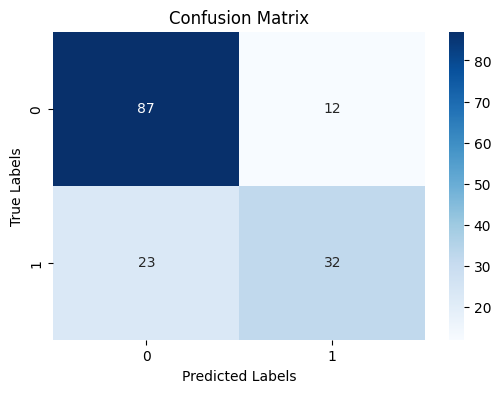

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

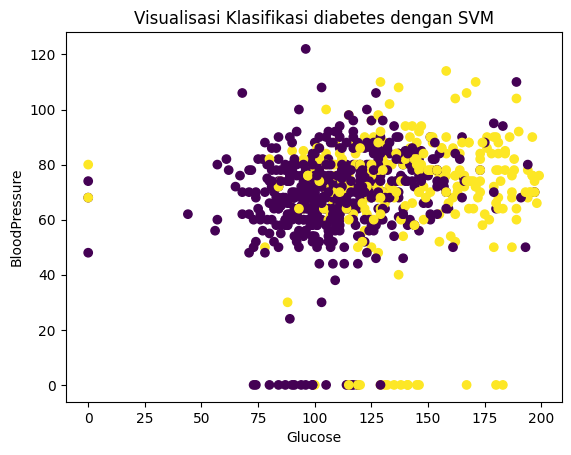

In [23]:
import matplotlib.pyplot as plt

plt.scatter(df['Glucose'], df['BloodPressure'], c=df['Outcome'].astype('category').cat.codes)
plt.xlabel('Glucose')
plt.ylabel('BloodPressure')
plt.title('Visualisasi Klasifikasi diabetes dengan SVM')
plt.show()

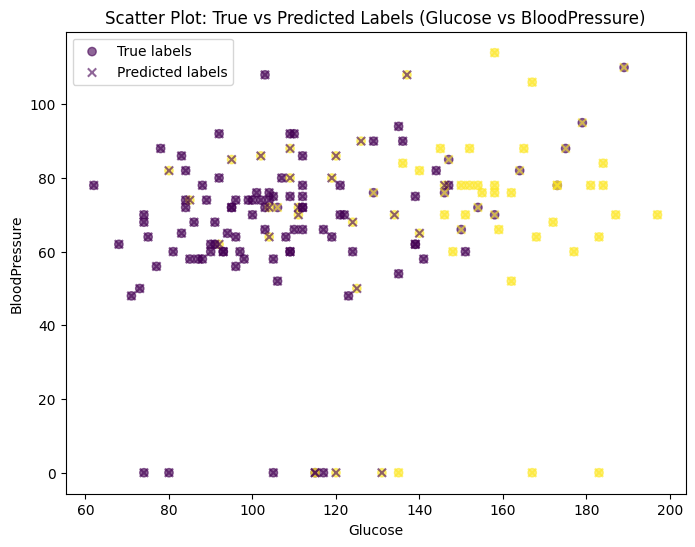

In [24]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# re-encode y_test for plotting
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)
y_pred_encoded = le.transform(y_pred)

plt.figure(figsize=(8, 6)) # untuk membuat canvas putih dengan ukuran 8, 6

# plot titik berdasarkan label asli
plt.scatter(X_test['Glucose'], X_test['BloodPressure'],
            c=y_test_encoded, cmap='viridis', marker='o', label='True labels', alpha=0.6)

# plot titik berdasarkan label prediksi
plt.scatter(X_test['Glucose'], X_test['BloodPressure'],
            c=y_pred_encoded, cmap='viridis', marker='x', label='Predicted labels', alpha=0.6)

plt.title('Scatter Plot: True vs Predicted Labels (Glucose vs BloodPressure)')
plt.xlabel('Glucose')
plt.ylabel('BloodPressure')
plt.legend()
plt.show()

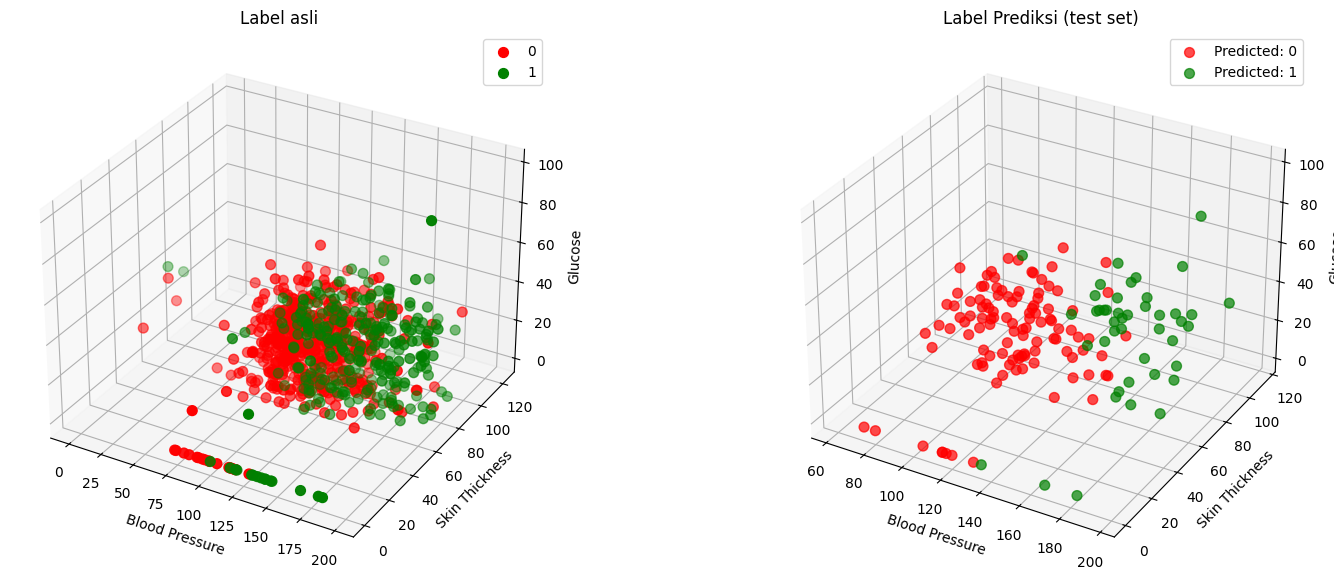

In [26]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 3. Encocde label (ubah teks jadi angka) - Moved from another cell
le = LabelEncoder()
df['OutcomeEncoded'] =  le.fit_transform(df['Outcome'])

# warna untuk tiap kelas
color = ['r', 'g', 'b']
labels = le.classes_

fig = plt.figure(figsize=(18,7))

# plot 1 : label asli
axl = fig.add_subplot(121, projection='3d')
for i, species in enumerate(labels):
  subset = df[df['OutcomeEncoded'] == i]
  axl.scatter(
      subset['Glucose'],
      subset['BloodPressure'],
      subset['SkinThickness'],
      color=color[i],
      label=species,
      s=50
  )
axl.set_title('Label asli')
axl.set_zlabel('Glucose')
axl.set_xlabel('Blood Pressure')
axl.set_ylabel('Skin Thickness')
axl.legend()

# plot 2 label prediksi
ax2 = fig.add_subplot(122, projection='3d')
# tambahkan hasil prediksi ke dataframe
# create a new column and initialize with none
df['Predicted'] = None
# assign predicted values to the rows that were in the test set
df.loc[X_test.index, 'Predicted'] = y_pred

#visualisasi 3d berdasarkan hasil prediksi
# warna untuk tiap kelas hasil preediksi
# Make sure to usee the encoded predicted labels for coloring
if df['Predicted'].dtype == 'object':
  predicted_encoded = le.transform(df.loc[X_test.index, 'Predicted'].dropna())
  df.loc[X_test.index, 'PredictedEncoded'] = np.nan # Initialize with NaN
  df.loc[X_test.index[~df.loc[X_test.index, 'Predicted'].isna()], 'PredictedEncoded'] = predicted_encoded # Assign values only for non-NaN predictions
  plot_column = 'PredictedEncoded'
else:
  plot_column = 'Predicted'

for i, species_label in enumerate(labels):
  subset = df.loc[X_test.index].dropna(subset=[plot_column])
  subset = subset[subset[plot_column] == i]

  ax2.scatter(
      subset['Glucose'],
      subset['BloodPressure'],
      subset['SkinThickness'],
      color=color[i],
      label=f"Predicted: {species_label}",
      s=50,
      alpha=0.7
  )

ax2.set_title('Label Prediksi (test set)')
ax2.set_zlabel('Glucose')
ax2.set_xlabel('Blood Pressure')
ax2.set_ylabel('Skin Thickness')
ax2.legend()

plt.show()